In [27]:
import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#print(f"Using device: {device}")


In [28]:
words = open('names.txt', 'r').read().splitlines()
split1 = int(len(words)*0.8)
split2 = int(len(words)*0.9)
words_train = words[:split1]
words_dev = words[split1:split2]
words_test = words[split2:]

chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

train loss - 2.3228914737701416; dev loss - 2.513819932937622
test loss - 2.5230817794799805
test cross entropy loss - 2.5230817794799805


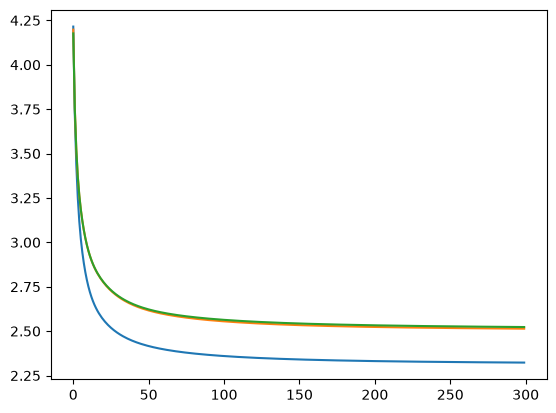

In [272]:


xs1_train, xs2_train, ys_train, xs1_dev, xs2_dev, ys_dev, xs1_test, xs2_test, ys_test = [],[],[],[],[],[],[],[],[]
for w in words_train: 
    chs = ['.','.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs,chs[1:], chs[2:]):
        xs1_train.append(stoi[ch1])
        xs2_train.append(stoi[ch2])
        ys_train.append(stoi[ch3])
for w in words_dev: 
    chs = ['.','.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs,chs[1:], chs[2:]):
        xs1_dev.append(stoi[ch1])
        xs2_dev.append(stoi[ch2])
        ys_dev.append(stoi[ch3])
for w in words_test: 
    chs = ['.','.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs,chs[1:], chs[2:]):
        xs1_test.append(stoi[ch1])
        xs2_test.append(stoi[ch2])
        ys_test.append(stoi[ch3])

#init
xs1_train = torch.tensor(xs1_train)
xs2_train = torch.tensor(xs2_train)
ys_train = torch.tensor(ys_train)

xs1_dev = torch.tensor(xs1_dev)
xs2_dev = torch.tensor(xs2_dev)
ys_dev = torch.tensor(ys_dev)

xs1_test = torch.tensor(xs1_test)
xs2_test = torch.tensor(xs2_test)
ys_test = torch.tensor(ys_test)

g = torch.Generator().manual_seed(1)
xenc1_train = F.one_hot(xs1_train,num_classes=27).float()
xenc2_train = F.one_hot(xs2_train,num_classes=27).float()
xenc_train = torch.cat((xenc1_train,xenc2_train),dim=1)

xenc1_dev = F.one_hot(xs1_dev,num_classes=27).float()
xenc2_dev = F.one_hot(xs2_dev,num_classes=27).float()
xenc_dev = torch.cat((xenc1_dev,xenc2_dev),dim=1)

xenc1_test = F.one_hot(xs1_test,num_classes=27).float()
xenc2_test = F.one_hot(xs2_test,num_classes=27).float()
xenc_test = torch.cat((xenc1_test,xenc2_test),dim=1)
W = torch.randn((54,27), generator=g, requires_grad=True)
num_train = xs1_train.nelement()
num_dev = xs1_dev.nelement()
num_test = xs1_test.nelement()

loss_train = []
loss_dev = []
loss_test = []

for k in range(300):

    #train forward
    logits_train = xenc_train @ W
    counts_train = logits_train.exp()
    probs_train = counts_train / counts_train.sum(1,keepdims=True)
    l_train = -probs_train[torch.arange(num_train), ys_train].log().mean()
    l_train_reg = l_train + 0.04*(W**2).mean();
    #print(l_train.item())
    loss_train.append(l_train.item())

    #dev forward
    logits_dev = xenc_dev @ W
    counts_dev = logits_dev.exp()
    probs_dev = counts_dev / counts_dev.sum(1,keepdims=True)
    l_dev = -probs_dev[torch.arange(num_dev), ys_dev].log().mean()
    #print(l_dev.item())
    loss_dev.append(l_dev.item())

    #test forward
    logits_test = xenc_test @ W
    counts_test = logits_test.exp()
    probs_test = counts_test / counts_test.sum(1,keepdims=True)
    l_test = -probs_test[torch.arange(num_test), ys_test].log().mean()
    #print(l_test.item())
    loss_test.append(l_test.item())

    #backward
    W.grad = None
    l_train_reg.backward()

    #update
    W.data += -25 * W.grad
plt.plot(loss_train)
plt.plot(loss_dev)
plt.plot(loss_test)
print(f'train loss - {l_train}; dev loss - {l_dev}')
print(f'test loss - {l_test}')
print(f'test cross entropy loss - {F.cross_entropy(logits_test,ys_test)}')
#Regularizaiton testing
#0.00001-> t 2.3192 d 2.5173 
#0.0001 -> t 2.3192 d 2.5173
#0.001  -> t 2.3192 d 2.5171
#0.01   -> t 2.3196 d 2.5156
#0.04   -> t 2.3228 d 2.5138 test 2.523
#0.05   -> t 2.3243 d 2.5139
#0.1    -> t 2.3332 d 2.5177
#1      -> t 2.4584 d 2.6153

In [ ]:
g = torch.Generator().manual_seed(1)
for k in range(10):
    out = []
    ix1 =  0
    ix2 =  0

    while True:
        xenc1 = F.one_hot(torch.tensor([ix1]),num_classes=27).float()
        xenc2 = F.one_hot(torch.tensor([ix2]),num_classes=27).float()
        xenc = torch.cat((xenc1,xenc2),dim=1)
        logits = xenc @ W # can be (W[xs1_train,:] + W[27+xs2_train,:]) but it is slower on small matrices
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(probs, num_samples=1,replacement = True, generator = g).item()
        if ix == 0:
            break
        out.append(itos[ix])

        ix1 = ix2
        ix2 = ix
    print(''.join(out))

aha
ele
lia
aldel
xalres
mel
abriartti
rielcirlenn
madlais
honera
